# ToBigs 정규세션 5주차 XAI 과제


# 1. Lime

In [2]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=e70f1948f5e22529089a2a692c643043ce4d7bcda7b423652f801db032125d46
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


### LIME (Local Interpretable Model-agnostic Explanations) 실습
LIME은 모델의 종류와 상관없이(Model-agnostic) 특정 데이터 포인트의 예측 결과를 국소적으로(Local) 설명하는 기법입니다.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lime import lime_tabular

# 1. 데이터 로드 (유방암 데이터셋)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target


In [2]:
# features
print(X.info())
print(y.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [3]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 분류 모델 생성 및 학습 (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


# LIME Explainer 초기화
explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=data.feature_names,
    class_names=data.target_names,
    mode='classification'
)

# 특정 데이터 샘플에 대해 설명 생성
# 테스트 셋의 첫 번째 데이터를 대상으로 설명 -> local explanation
i = 0
exp = explainer.explain_instance(
    data_row=X_test.iloc[i],
    predict_fn=rf_model.predict_proba,
    num_features=5 # 상위 5개 주요 feature만
)

# 결과 시각화
print(f'실제 라벨: {data.target_names[y_test[i]]}')
print(f'모델의 예측 확률: {rf_model.predict_proba(X_test.iloc[[i]])}')

# 노트북 내에서 시각화 결과 출력
exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

실제 라벨: benign
모델의 예측 확률: [[0.03 0.97]]


Q1. LIME의 핵심 동작 과정에 대해서 서술해주세요.

답: LIME은 특정 데이터 포인트 하나에 대한 모델의 예측을 설명하기 위해, 그 데이터 주변에서 모델의 행동을 국소적으로 근사하는 방식으로 작동한다. 먼저 설명하고자 하는 데이터 하나를 선택한 뒤, 해당 데이터와 유사하지만 일부 feature 값이 조금씩 변형된 새로운 샘플들을 다수 생성한다. 이렇게 생성된 데이터들을 원래의 복잡한 모델에 입력하여 각각의 예측 결과를 얻는다. 이후 원본 데이터와의 유사도를 기준으로 가까운 데이터일수록 더 큰 가중치를 부여하여, 국소적인 영역을 강조한다. 그 다음, 이 가중치가 반영된 데이터와 예측 결과를 이용해 해석이 가능한 단순한 모델을 학습시키는데, 이 모델이 바로 surrogate model이다. 마지막으로 이 단순 모델의 계수를 통해 각 feature가 예측에 미친 영향력을 파악함으로써, 원래 모델의 예측을 사람이 이해할 수 있는 형태로 설명한다. 즉, LIME은 복잡한 모델 자체를 직접 해석하는 것이 아니라, 특정 데이터 주변에서 단순한 모델로 근사하여 설명을 제공하는 방식이다.

Q2. LIME model에서의 surrogate model의 역할을 설명해주세요.

답: LIME에서 surrogate model은 복잡한 모델의 예측을 해석 가능하게 만드는 핵심적인 역할을 수행한다. 일반적으로 Random Forest나 신경망과 같은 모델은 높은 성능을 가지지만 내부 구조가 복잡하여 해석이 어렵다. 이에 반해 surrogate model은 선형 회귀와 같이 구조가 단순하고 해석이 쉬운 모델로 구성되어, 특정 데이터 주변에서 원래 모델의 동작을 근사한다. 이 모델은 전체 데이터 분포를 설명하는 것이 아니라, 설명 대상 데이터 근처의 국소적인 영역에서만 모델의 행동을 모사한다는 점이 중요하다. surrogate model을 통해 각 feature의 계수를 확인하면, 해당 feature가 예측값을 증가시키는지 감소시키는지, 그리고 그 영향의 크기가 어느 정도인지를 직관적으로 이해할 수 있다. 따라서 surrogate model은 복잡한 모델의 예측 결과를 사람이 이해할 수 있는 형태로 변환해주는 해석 도구로서, LIME의 핵심적인 구성 요소라고 할 수 있다.

---

#2. SHAP

In [1]:
!pip install shap

### SHAP (SHapley Additive exPlanations)
SHAP은 게임 이론의 Shapley Value를 기반으로, 각 특성이 모델의 예측값에 얼마나 기여했는지를 수치화하여 설명하는 기법입니다.

--- 전체 데이터의 특성 중요도 (Summary Plot) ---


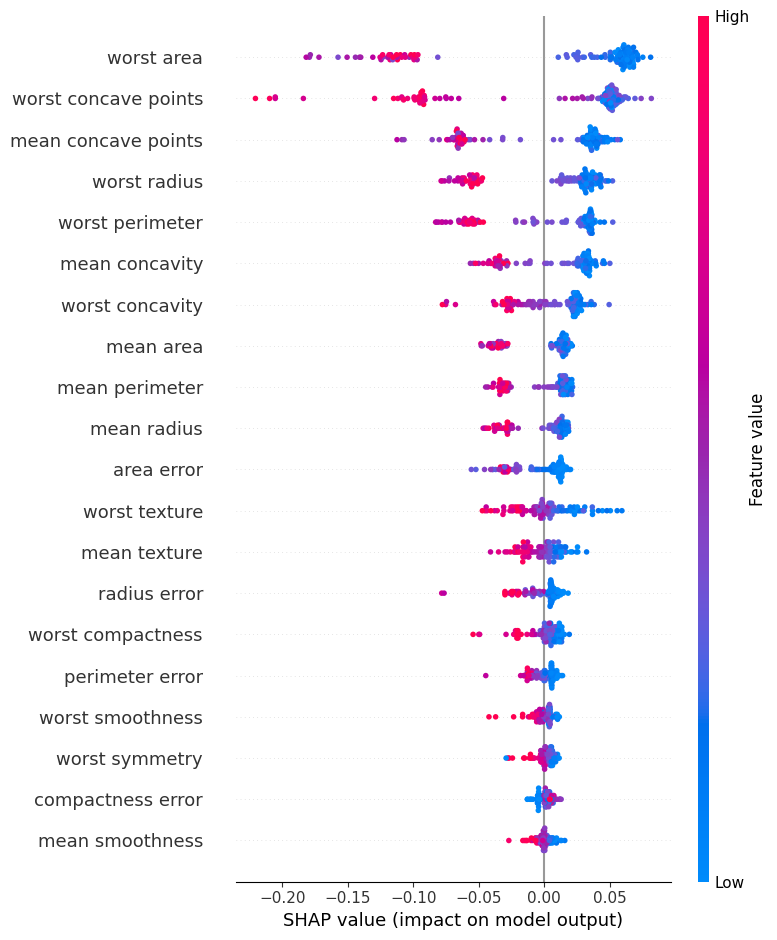

In [4]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# SHAP Explainer 초기화, ML 모델을 argument로
explainer_shap = shap.TreeExplainer(rf_model)

# SHAP Value 계산
shap_values = explainer_shap.shap_values(X_test)

# 결과 시각화 준비
if isinstance(shap_values, list):

    target_shap_values = shap_values[1]
    base_value = explainer_shap.expected_value[1]
else:
    if len(shap_values.shape) == 3:
        target_shap_values = shap_values[:, :, 1]
        base_value = explainer_shap.expected_value[1]
    else:
        target_shap_values = shap_values
        base_value = explainer_shap.expected_value

# Summary plot -> feature importance
print("--- 전체 데이터의 특성 중요도 (Summary Plot) ---")
shap.summary_plot(target_shap_values, X_test)


Q3. SHAP Value가 양수인 특성과 음수인 특성은 각각 예측 결과에 어떤 영향을 주는지 서술하세요.

답: SHAP Value는 각 특성이 특정 데이터 포인트의 모델 예측값에 기여하는 정도를 수치화한 값으로, 양수와 음수의 의미가 명확히 구분된다. 특정 데이터 포인트에서 어떤 특성의 SHAP Value가 양수라는 것은, 그 특성이 모델이 예측한 목표 클래스의 확률을 증가시키는 방향으로 기여했다는 것을 의미한다. 반대로 SHAP Value가 음수인 경우에는 해당 특성이 예측값을 감소시키는 방향으로 영향을 주었다는 뜻이다. 즉, SHAP Value를 통해 각 특성이 개별 데이터에 대해 예측을 밀어 올렸는지 내렸는지를 직관적으로 이해할 수 있으며, 이를 통해 모델의 예측 과정을 보다 세밀하게 해석할 수 있다.


Q4. 기존 Tree 기반 ML Model(RF)에서 사용하는 entropy 혹은 geni index 기반 feature importance와 SHAP의 feature importance의 차이점을 서술하세요.

답: 전통적인 Random Forest나 Decision Tree에서 사용하는 feature importance는 보통 엔트로피(entropy)나 지니 지수(Gini index)를 기반으로 각 특성이 분할(split)에 기여한 정도를 누적하여 계산한다. 이러한 중요도는 전체 학습 데이터에서 평균적으로 얼마나 자주, 얼마나 큰 정보 이득을 가져왔는지를 나타내며, 개별 데이터 포인트별 영향은 반영되지 않는다. 반면 SHAP의 feature importance는 각 데이터 포인트에 대한 SHAP Value를 평균하여 산출되며, 이는 모델의 예측값에 실제로 각 특성이 얼마나 기여했는지를 모든 조합의 가능성을 고려해 공정하게 계산한 값이다. 따라서 SHAP feature importance는 단순히 분할 횟수나 정보 이득뿐 아니라, 특성이 예측값에 미친 실제 기여도를 반영하므로 더 직관적이고 개별 예측에 대한 해석 가능성이 뛰어나며, 데이터 불균형이나 상호작용 효과까지 고려할 수 있다는 장점이 있다.

---

# 3. Grad-CAM

### Grad-CAM (Gradient-weighted Class Activation Mapping)
Grad-CAM은 CNN 기반의 딥러닝 모델이 이미지의 어떤 영역을 보고 특정 클래스로 분류했는지를 중요도에 따라 히트맵(Heatmap) 형태로 시각화하는 기법입니다. 특성 맵(Feature Map)에 흐르는 그래디언트 정보를 사용하여 가중치를 계산합니다.

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 74.3MB/s]


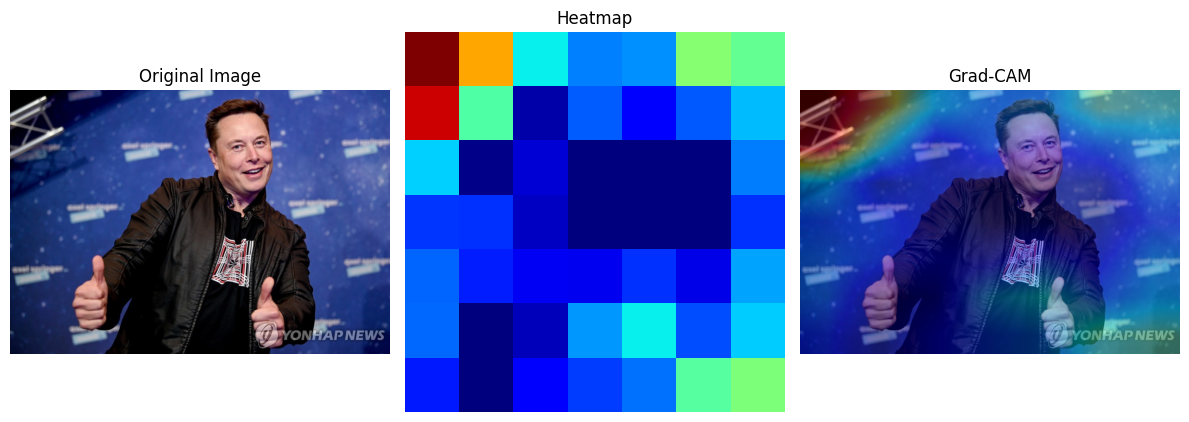

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import requests
from io import BytesIO

# 1. 사전 학습된 모델 로드 (VGG16)
# weights 매개변수를 사용하여 최신 방식으로 로드합니다.
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model.eval()

# 그래디언트와 특성 맵을 저장할 변수
gradients = None
activations = None

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

def forward_hook(module, input, output):
    global activations
    activations = output

# 마지막 컨볼루션 층에 훅 등록 (VGG16의 경우 features의 30번 레이어)
target_layer = model.features[30]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# 2. 이미지 로드 및 전처리
url = 'https://img2.yna.co.kr/photo/etc/epa/2020/12/02/PEP20201202052601055_P4.jpg'
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img).unsqueeze(0)

# 3. 모델 예측 및 Grad-CAM 계산
output = model(input_tensor)
pred_index = output.argmax(dim=1).item()

# 역전파 수행
model.zero_grad()
output[0, pred_index].backward()

# 4. Grad-CAM 히트맵 생성
# 글로벌 평균 풀링 (GAP)을 통한 가중치 미분값 계산
weights = torch.mean(gradients, dim=(2, 3), keepdim=True)

# 특성 맵과 가중치 결합
heatmap = torch.sum(weights * activations, dim=1).squeeze()
heatmap = F.relu(heatmap) # ReLU 적용 (양의 영향만 고려)

# 0~1 사이 정규화
if torch.max(heatmap) != 0:
    heatmap /= torch.max(heatmap)
heatmap = heatmap.detach().cpu().numpy()

# 5. 결과 시각화
img_cv = np.array(img)
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)

# 히트맵 리사이즈 및 컬러맵 적용
heatmap_resized = cv2.resize(heatmap, (img_cv.shape[1], img_cv.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

# 원본과 합성 (Bayer 변환 고려)
superimposed_img = cv2.addWeighted(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB), 0.6, cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB), 0.4, 0)

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Heatmap')
plt.imshow(heatmap, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Grad-CAM')
plt.imshow(superimposed_img)
plt.axis('off')

plt.tight_layout()
plt.show()

Q5. Grad-CAM에서 마지막 컨볼루션 층(Last Conv Layer)의 정보를 사용하는 이유는 무엇인가요?

답: Grad-CAM에서 마지막 컨볼루션 층을 사용하는 이유는, 이 층이 공간적 정보를 유지하면서도 고수준의 의미(feature)를 잘 추출하기 때문이다. CNN의 초기 층은 가장자리, 색상, 질감 등 저수준 특징만 인식하고, 완전연결층(FC) 쪽으로 갈수록 점점 추상적인 정보만 남아 공간적 위치 정보가 사라진다. 따라서 마지막 컨볼루션 층을 사용하면, 모델이 특정 클래스 예측에 주목한 이미지 내 영역을 히트맵 형태로 정확히 시각화할 수 있다. 이 층의 특성 맵과 해당 클래스에 대한 그래디언트를 결합함으로써, 모델이 어디를 보고 예측했는지를 국소적으로 강조할 수 있다.

Q6. Grad-CAM 결과에서 붉게 표시되는 영역(High Activation)은 모델 판단에 어떤 의미를 갖는지 서술하세요.

답: Grad-CAM에서 히트맵 상 붉게 표시되는 영역은 모델이 해당 클래스의 예측을 수행할 때 가장 큰 영향을 준 이미지 영역을 의미한다. 즉, 모델이 특정 객체를 “주목”한 부분이며, 이 영역의 특징이 예측 확률을 높이는 방향으로 기여했다는 뜻이다. 반대로 파란색이나 낮은 값으로 표시되는 영역은 예측에 상대적으로 덜 기여했거나 부정적인 영향을 준 부분으로 해석할 수 있다. 따라서 붉은 영역을 보면 모델의 판단 근거가 시각적으로 직관적으로 드러난다.

Q7. Grad-CAM 으로 시각화 한 heatmap이 과연 이미지의 중요한 객체를 담고 있는지 서술하세요. 만약 아니라면 본인이 생각하는 이유를 작성해주세요.

답: Grad-CAM은 일반적으로 모델이 예측에 주목한 영역을 시각화하지만, 반드시 이미지 내 인간이 생각하는 “중요 객체”와 일치하지는 않을 수 있다. 이는 모델이 학습 과정에서 데이터 편향이나 주변 배경, 텍스처 등 클래스와 상관된 패턴을 학습했을 가능성이 있기 때문이다. 예를 들어, 고양이 이미지에서 실제 고양이 몸보다 배경의 특정 색상이나 패턴에 주목할 수 있으며, Grad-CAM은 이를 붉게 표시한다. 따라서 heatmap은 모델이 실제로 무엇을 기반으로 예측했는지를 보여주지만, 항상 인간의 직관과 일치하지는 않으며, 모델의 학습 특성과 편향을 반영한다.

---

## Quantifying Attention Flow in Transformers 논문 실험해보기(Image)


논문에서 제시된 Attention Rollout을 구현해 분석해보겠습니다.

In [11]:
# 이미지 로드 및 전처리
url = "https://avatars.githubusercontent.com/u/59883115?v=4"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img).unsqueeze(0)

In [12]:
from transformers import ViTForImageClassification, ViTConfig

# 모델 설정에서 output_attentions를 명시적으로 True로 설정
config = ViTConfig.from_pretrained("google/vit-base-patch16-224", output_attentions=True)
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224", config=config)

device = torch.device("cpu")
model = model.to(device)
input_tensor = input_tensor.to(device)
model.eval()

with torch.no_grad():
    # 모델 호출 시에도 다시 한 번 명시
    outputs = model(input_tensor, output_attentions=True)

# Attention 추출
attentions = outputs.attentions

if attentions is not None:
    print(f"num_layers: {len(attentions)}")
    print(f"attention shape of one layer: {attentions[0].shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

num_layers: 12
attention shape of one layer: torch.Size([1, 12, 197, 197])


In [13]:
# rollout function
def attention_rollout(attentions):
    """
    attentions:
        tuple/list of attention tensors
        each tensor shape = (B, H, N, N)

    return:
        rollout: (B, N, N)
    """
    batch_size = attentions[0].shape[0]
    num_tokens = attentions[0].shape[-1]
    device = attentions[0].device

    # 초기값: identity 행렬(torch.eye)
    rollout = torch.eye(num_tokens, device=device).unsqueeze(0).repeat(batch_size, 1, 1)

    for attention in attentions:
        # 1) head fusion: mean(N개의 Attention Head를 어떻게 aggregation 할지, 여기서는 평균)
        attn = attention.mean(dim=1)   # (B, N, N)

        # 2) residual connection 반영(identity matrix를 더함)
        I = torch.eye(num_tokens, device=device).unsqueeze(0).repeat(batch_size, 1, 1)
        attn = attn + I

        # 3) row normalization(행의 합을 1로 맞춰줌)
        attn = attn / attn.sum(dim=-1, keepdim=True)

        # 4) rollout: 계속 곱함
        rollout = torch.bmm(attn, rollout)

    return rollout

In [14]:
with torch.no_grad():
    outputs = model(input_tensor, output_attentions=True)

attentions = outputs.attentions

print("num_layers:", len(attentions))
print("one attention shape:", attentions[0].shape)

num_layers: 12
one attention shape: torch.Size([1, 12, 197, 197])


In [15]:
# Rollout 계산
rollout = attention_rollout(attentions)   # (B, N, N)

# 첫 번째 배치 사용
rollout_map = rollout[0]   # (N, N)

# CLS token -> patch tokens
cls_attention = rollout_map[0, 1:]   # (num_patches,)

In [16]:
# patch map으로 변환
num_patches = cls_attention.shape[0]
grid_size = int(np.sqrt(num_patches))

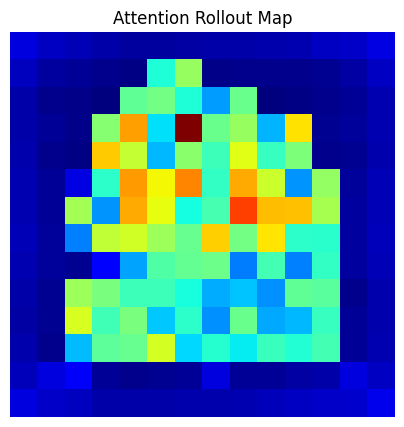

In [17]:
mask = cls_attention.reshape(grid_size, grid_size).detach().cpu().numpy()

# 0~1 정규화
mask = mask - mask.min()
mask = mask / (mask.max() + 1e-8)

# heatmap 시각화
plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap="jet")
plt.title("Attention Rollout Map")
plt.axis("off")
plt.show()


# 원본 이미지 복원(input_tensor가 normalize 되었기 때문에 다시 복원)

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
def denormalize_image(img_tensor, mean, std):
    """
    img_tensor: (3, H, W)
    """
    mean = torch.tensor(mean, device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor(std, device=img_tensor.device).view(3, 1, 1)
    img = img_tensor * std + mean
    img = img.clamp(0, 1)
    return img
img = denormalize_image(input_tensor[0], mean, std)
img = img.permute(1, 2, 0).detach().cpu().numpy()   # (H, W, 3)



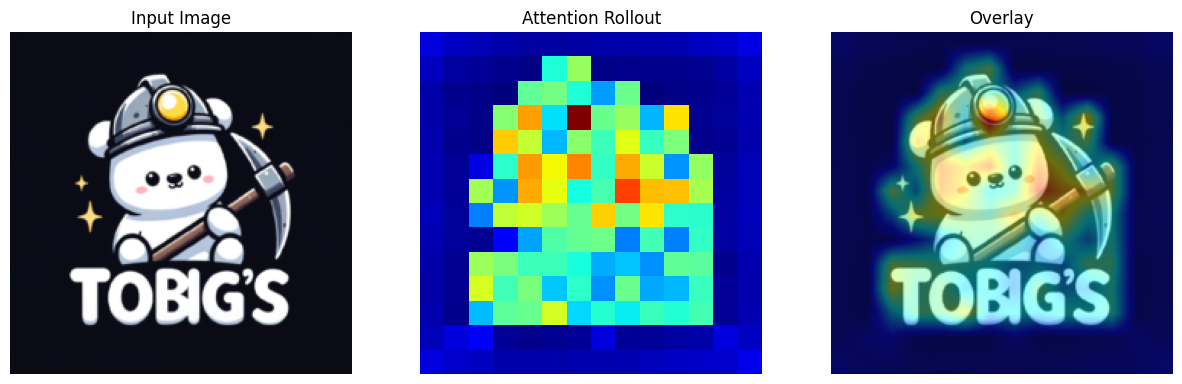

In [18]:
# 그림 시각화
H, W, _ = img.shape
mask_resized = cv2.resize(mask, (W, H))

heatmap = cv2.applyColorMap(np.uint8(255 * mask_resized), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

overlay = 0.6 * img + 0.4 * heatmap
overlay = np.clip(overlay, 0, 1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="jet")
plt.title("Attention Rollout")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.show()

Q8. 기존의 Attention Score 기반 explanation 말고 위와 같은 Attention rollout 방법을 사용하는 이유를 알려주세요.

답: 기존의 단순한 Attention Score 기반 설명은 각 레이어나 각 헤드의 attention 값을 개별적으로 관찰하는 방식으로, 특정 토큰이나 이미지 패치가 모델 예측에 얼마나 영향을 주었는지를 한눈에 보기 어렵다는 한계가 있다. 반면 Attention Rollout은 모든 레이어와 헤드를 순차적으로 결합하여 CLS 토큰이 최종적으로 각 패치나 토큰에 얼마나 영향을 받았는지를 종합적으로 계산한다. 이를 통해 단일 레이어에서의 국소적인 attention 값이 아니라, 모델의 전체적인 정보 흐름을 고려한 전역적인 중요도 지도(global importance map)를 얻을 수 있다. 즉, 단순히 attention이 높은 패치를 보는 것이 아니라, 층을 거치며 누적된 영향력을 반영하여 모델이 실제 예측을 위해 주목한 영역을 보다 정확하게 시각화할 수 있게 된다.

(Optional) Q9. Attention Score를 기반으로 해석한, Score가 높은 word token 혹은 patch token으로 어떤 방법론을 만들 수 있을까요?(EX. ViT에서 Attention Score가 높은 patch token들을 따로 모아서 세밀한 부분을 구별하는 discriminative features로 사용 등)

답: Attention Score가 높은 토큰이나 패치를 추출하면, 이를 기반으로 다양한 downstream 활용이 가능하다. 예를 들어 ViT에서 주목도가 높은 이미지 패치를 선택하여 세밀한 객체 영역을 강조하거나 분류 성능 향상을 위한 discriminative feature로 사용할 수 있다. 자연어 처리에서는 attention이 높은 단어 토큰을 기반으로 핵심 문장 요약, 질문-답변 매칭, 또는 중요 키워드 기반 설명 생성 등에 활용할 수 있다. 또한, 이런 중요 토큰이나 패치를 이용해 모델 압축, 경량화, 또는 인터프리터블 AI 개발에도 적용할 수 있다. 즉, 단순히 attention 값을 보는 것을 넘어, 모델이 실제로 집중한 핵심 정보만을 추출하여 설명 가능성과 성능 개선에 활용할 수 있는 방법론으로 확장할 수 있다.